# plot points

In [1]:

import torch
import numpy as np
import matplotlib.pyplot as plt

def vandercorput(n, base):
    """
    Vectorized van der Corput for n = array-like nonnegative integers and given base.
    Returns array of same shape as n with values in [0,1).
    """
    n = np.asarray(n, dtype=np.int64)
    # compute digits for each n by repeated division
    out = np.zeros_like(n, dtype=np.float64)
    denom = base
    current = n.copy()
    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current = current // base
        denom *= base
    return out

def halton_sequence(N, dim):
    """
    Generate first N points of Halton sequence in `dim` dimensions.
    Uses first `dim` primes as bases.
    Returns array shape (N, dim) with values in [0,1).
    """
    # small prime list sufficient for moderate dim
    primes_list = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59]
    if dim > len(primes_list):
        raise ValueError("Requested dimension too large for built-in primes list.")
    bases = primes_list[:dim]
    n_idx = np.arange(0, N, dtype=np.int64)  # n = 0..N-1
    H = np.empty((N, dim), dtype=np.float64)
    for j, b in enumerate(bases):
        H[:, j] = vandercorput(n_idx, b)
    return H

def generator_points_star(N_patch_grid,
                     N_local_per_patch,
                     N_boundary,
                     R_ptch,
                     mode="c-rbf-pum"):
    """
    Generate points on a star-shaped region and patch covering.

    Parameters
    ----------
    N_patch_grid : int
        number of patches per dimension (grid)
    N_local_per_patch : int
        target local points per patch (used as halton sample size per patch)
    N_boundary : int
        number of boundary points
    R_ptch : float
        patch radius
    mode : str
        "c-rbf-pum" or "ls-rbf-pum"

    Returns
    -------
    X_inner : ndarray (N_x,2)
        concatenated interior/source points
    X_boundary : ndarray (N_boundary,2)
        boundary points (uniform in theta)
    ptch : dict
        {'C': array(P,2), 'R': array(P,) } patch centers and radii
    grid_eval : ndarray (N_eval,2)
        evaluation/prediction points (depends on mode)
    """
    # -------------------------
    # 1. star region radial function
    def r_max_func(theta):
        return 2.0 * (0.7 + 0.12 * (np.sin(6*theta) + np.sin(3*theta)))

    # vector theta for plotting / sampling
    theta_plot = np.linspace(0.0, 2*np.pi, 1000, endpoint=False)
    r_plot = r_max_func(theta_plot)
    x_plot = r_plot * np.cos(theta_plot)
    y_plot = r_plot * np.sin(theta_plot)

    x_min, x_max = x_plot.min(), x_plot.max()
    y_min, y_max = y_plot.min(), y_plot.max()
    R_container = r_plot.max()

    # helper: is point(s) inside star region (vectorized)
    def is_inside_star(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        r = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        theta = np.where(theta < 0, theta + 2*np.pi, theta)
        r_limit = r_max_func(theta)
        TOL = 1e-12
        return r <= (r_limit + TOL)

    # -------------------------
    # 2. Patch grid parameters
    Domain_size = max(x_max - x_min, y_max - y_min)
    num_patches_1D = int(N_patch_grid)
    # avoid division by zero when Domain_size small
    if num_patches_1D <= 1:
        del_param = 0.0
    else:
        del_param = (num_patches_1D - Domain_size / R_ptch) / (num_patches_1D - 1)
    patch_spacing = 2 * R_ptch * (1 - del_param)

    # create center grid in bounding square [Grid_min, Grid_max]^2
    Grid_min = min(x_min, y_min)
    Grid_max = max(x_max, y_max)
    Cx = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cy = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cxv, Cyv = np.meshgrid(Cx, Cy)
    C_all = np.column_stack([Cxv.ravel(), Cyv.ravel()])
    R_all = R_ptch * np.ones((C_all.shape[0],), dtype=np.float64)

    # For each candidate patch, sample its circle boundary points and check overlap
    theta_circ = theta_plot  # reuse dense sample
    # build for all centers: shifted circle coordinates
    # shape (num_centers, n_theta)
    bc_x = C_all[:, 0:1] + R_all[:, None] * np.cos(theta_circ)[None, :]
    bc_y = C_all[:, 1:] + R_all[:, None] * np.sin(theta_circ)[None, :]

    # Determine which patch has any boundary point inside the star region
    # is_inside_star accepts arrays; compute over all boundary samples
    inside_flags = is_inside_star(bc_x, bc_y)  # shape (num_centers, n_theta)
    id_keep = np.where(inside_flags.sum(axis=1) > 0)[0]

    C_kept = C_all[id_keep, :]
    R_kept = R_all[id_keep]
    ptch = {'C': C_kept, 'R': R_kept}
    P = C_kept.shape[0]

    # -------------------------
    # 3. Generate RBF center points per patch (Halton sampling in polar coords)
    X_inner_points = []
    grid_eval_points = []  # for c-rbf-pum mode
    # we will use exactly N_local_per_patch halton samples per patch (as in your adjusted code)
    N_generate = int(N_local_per_patch)
    # for LS mode, generate global evaluation grid if requested
    if mode == "ls-rbf-pum":
        # create a dense grid that covers the bounding box and then trim to star region
        n_grid = int(round(np.sqrt(P * N_generate) * 1.5))
        if n_grid < 2:
            n_grid = 2
        x_eval = np.linspace(x_min, x_max, n_grid)
        y_eval = np.linspace(y_min, y_max, n_grid)
        Xg, Yg = np.meshgrid(x_eval, y_eval)
        grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])
        mask_grid = is_inside_star(grid_pts[:, 0], grid_pts[:, 1])
        grid_eval_all = grid_pts[mask_grid, :]
    else:
        grid_eval_all = np.empty((0, 2))

    # Halton base samples for polar mapping (u,v)
    H = halton_sequence(N_generate, 2)  # (N_generate, 2)
    u = H[:, 0]
    v = H[:, 1]

    for i in range(P):
        C = C_kept[i, :]
        R = R_kept[i]
        theta_local = 2.0 * np.pi * u  # (N_generate,)
        r_local = np.sqrt(v) * R
        x_local = r_local * np.cos(theta_local) + C[0]
        y_local = r_local * np.sin(theta_local) + C[1]
        if mode == "c-rbf-pum":
            inside_mask = is_inside_star(x_local, y_local)
            X_candidate = np.column_stack([x_local[inside_mask], y_local[inside_mask]])
            # keep all that are inside; you may trim to desired count elsewhere
            X_inner_points.append(X_candidate)
            grid_eval_points.append(X_candidate)
        elif mode == "ls-rbf-pum":
            # do not clip to patch by star region (as MATLAB's ls mode keeps all)
            X_candidate = np.column_stack([x_local, y_local])
            X_inner_points.append(X_candidate)
            # N_total in MATLAB set to P * N_generate; we follow that
        else:
            raise ValueError("Unrecognized mode: {}".format(mode))

    if len(X_inner_points) > 0:
        X_inner = np.vstack([arr for arr in X_inner_points if arr.shape[0] > 0])
    else:
        X_inner = np.empty((0, 2))

    if mode == "c-rbf-pum":
        # grid_eval collects retained candidates
        if len(grid_eval_points) > 0:
            grid_eval = np.vstack([arr for arr in grid_eval_points if arr.shape[0] > 0])
        else:
            grid_eval = np.empty((0, 2))
    else:
        grid_eval = grid_eval_all

    # -------------------------
    # 4. Generate boundary points (uniform in theta)
    theta_bnd = np.linspace(0.0, 2*np.pi, N_boundary, endpoint=False)
    r_bnd = r_max_func(theta_bnd)
    x_bnd = r_bnd * np.cos(theta_bnd)
    y_bnd = r_bnd * np.sin(theta_bnd)
    X_boundary = np.column_stack([x_bnd, y_bnd])

    # also return boundary curve for plotting convenience
    boundary_curve = np.column_stack([x_plot, y_plot])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve


# --------------------------
# Plotting wrapper
# --------------------------
def plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve, figsize1=(7,6), figsize2=(7,6)):
    """
    Draw two figures similar to MATLAB version:
    - Figure 1: patch coverage, interior points, boundary points, region boundary
    - Figure 2: prediction grid and boundary
    """
    C = ptch['C']
    R = ptch['R']
    P = C.shape[0]
    theta_circ = np.linspace(0, 2*np.pi, 200)

    # Figure 1
    plt.figure(figsize=figsize1)
    ax = plt.gca()
    # patch circles (dashed)
    for i in range(P):
        x_circ = C[i,0] + R[i] * np.cos(theta_circ)
        y_circ = C[i,1] + R[i] * np.sin(theta_circ)
        ax.plot(x_circ, y_circ, linestyle=':', color='k', linewidth=1.2)
        ax.plot(C[i,0], C[i,1], marker='x', color='g', markersize=6)
    # region boundary
    ax.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    # interior points
    if X_inner.shape[0] > 0:
        ax.scatter(X_inner[:,0], X_inner[:,1], s=10, c='b', marker='.', label='Interior points')
    # boundary points
    if X_boundary.shape[0] > 0:
        ax.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary points')
    ax.set_aspect('equal', 'box')
    ax.set_title('Patch Coverage and Node Distribution in the Star-Shaped Domain', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    # Figure 2: prediction grid
    plt.figure(figsize=figsize2)
    ax2 = plt.gca()
    ax2.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    if grid_eval is not None and grid_eval.shape[0] > 0:
        ax2.scatter(grid_eval[:,0], grid_eval[:,1], s=8, c='r', marker='.', label='Evaluation Points')
    if X_boundary.shape[0] > 0:
        ax2.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary Points')
    ax2.set_aspect('equal', 'box')
    ax2.set_title('Evaluation Point Distribution in the Star-Shaped Domain', fontsize=12)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()


number of patches = 22
number of source points = 814
number of boundary points = 600
number of evaluation points = 814


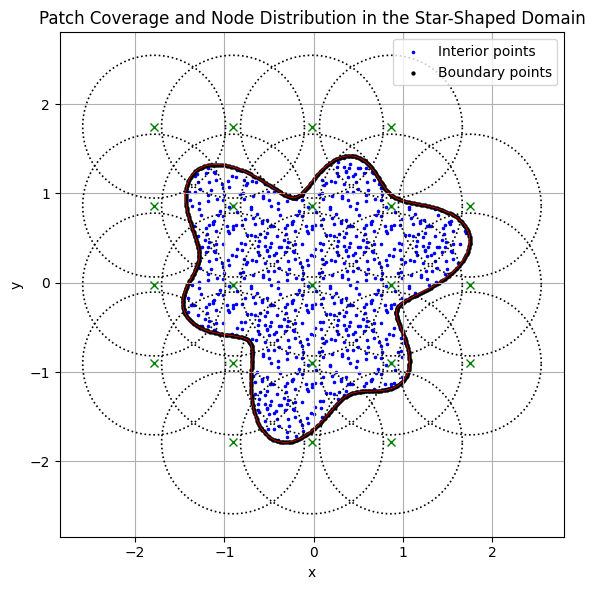

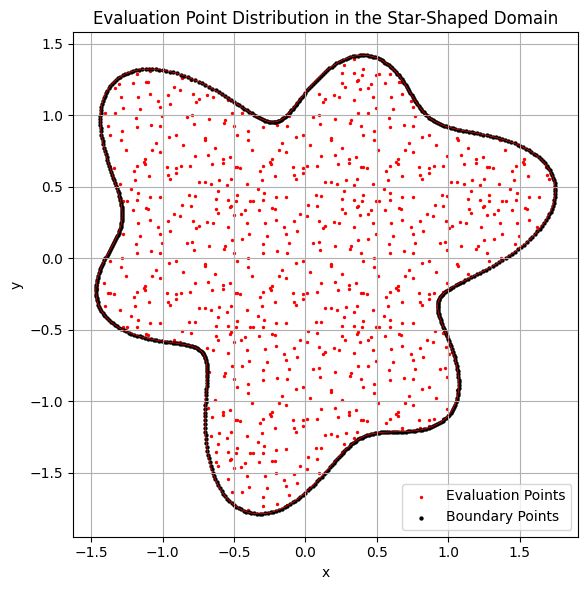

In [2]:

# =========================================================
# main
# =========================================================
if __name__ == "__main__":

    # -------------------------
    # parameters
    # -------------------------
    N_patch_grid = 5
    N_local_per_patch = 100
    N_boundary = 600
    R_ptch = 0.8
    mode = "c-rbf-pum"   # or "ls-rbf-pum"

    # -------------------------
    # generate points
    # -------------------------
    X_inner, X_boundary, ptch, grid_eval, boundary_curve = generator_points_star(
        N_patch_grid=N_patch_grid,
        N_local_per_patch=N_local_per_patch,
        N_boundary=N_boundary,
        R_ptch=R_ptch,
        mode=mode
    )

    print(f"number of patches = {ptch['C'].shape[0]}")
    print(f"number of source points = {X_inner.shape[0]}")
    print(f"number of boundary points = {X_boundary.shape[0]}")
    print(f"number of evaluation points = {grid_eval.shape[0]}")

    # =====================================================
    # Figure 1: patches + source points
    # =====================================================
    plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve, figsize1=(6,6), figsize2=(6,6))



In [2]:

import torch
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import scipy, time
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.spatial import cKDTree, distance
from scipy.spatial.distance import cdist
from scipy.linalg import lu_factor, lu_solve, cholesky, solve_triangular
from scipy.sparse import lil_matrix, diags
from scipy.sparse.linalg import spsolve, splu, lsmr, eigs
from math import pi


dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

def relative_loss(predict, exact):
    error = torch.sqrt(torch.sum((predict - exact) ** 2)) / torch.sqrt(torch.sum((exact) ** 2))
    return error

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True)

	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(6.2)**2 * x**2)
        output = self.input_layer(x)
        output = torch.sigmoid(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K: 
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    # nn.init.uniform_(m.bias, -np.pi, np.pi)
                    # nn.init.uniform_(m.bias, -1, 1)
                    nn.init.constant_(m.bias, 0.0)





def laplacian_phi_wrt_y(phi_net, y, X, eps):
    """
    Parameters
    ----------
    y : array-like or tensor, shape (M, 2)
        Evaluation points.
    X : array-like or tensor, shape (K, 2)
        Source points.
    Returns
    -------
    phi_vals : ndarray, shape (M, K)
    lap_y    : ndarray, shape (M, K)
    grad_y   : ndarray, shape (M, K, 2)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    if y.dim() == 1:
        y = y.unsqueeze(0)      # (1, 2)
    M = y.shape[0]
    K = X.shape[0]
    n = y.shape[1]              # dimension (=2)
    # --------------------------------------------------
    # pairwise difference: (M, K, 2)
    # --------------------------------------------------
    diff = y[:, None, :] - X[None, :, :]      # (M, K, 2)
    # radial distance: (M, K, 1)
    r = torch.norm(diff, dim=2, keepdim=True) # (M, K, 1)
    r = r.clamp(min=eps)
    r.requires_grad_(True)
    # --------------------------------------------------
    # radial basis evaluation
    # --------------------------------------------------
    phi_vals = phi_net(r)       # (M, K, 1)
    # phi'(r)
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True
    )[0]                        # (M, K, 1)

    # phi''(r)
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False,
        retain_graph=True
    )[0]                        # (M, K, 1)
    # --------------------------------------------------
    # Laplacian wrt y
    # Δ_y φ = φ''(r) + (n-1)/r φ'(r)
    # --------------------------------------------------
    lap_y = d2phi_dr2 + (n - 1) / r * dphi_dr  # (M, K, 1)
    # --------------------------------------------------
    # Gradient wrt y
    # ∇_y φ = φ'(r) * (y - x) / r
    # --------------------------------------------------
    grad_y = dphi_dr * diff / r                # (M, K, 2)
    # --------------------------------------------------
    # reshape outputs
    # --------------------------------------------------
    phi_vals = phi_vals.squeeze(-1).detach().cpu().numpy()  # (M, K)
    lap_y    = lap_y.squeeze(-1).detach().cpu().numpy()     # (M, K)
    grad_y   = grad_y.detach().cpu().numpy()                # (M, K, 2)
    return phi_vals, lap_y, grad_y

# # ===========================================================
def wendland_C2(r):
    return (4.0 * r + 1.0) * np.maximum(0.0, 1.0 - r)**4

def shepard_weights(x, ptch_C, ptch_R):
    diff = x[:, None, :] - ptch_C[None, :, :]
    r_dist = np.linalg.norm(diff, axis=2)    # M × Nc
    r_scaled = r_dist / ptch_R[None, :]      # M × Nc
    Varphi_matrix = wendland_C2(r_scaled)    # M × Nc
    Sum_Varphi = np.sum(Varphi_matrix, axis=1, keepdims=True)  # M × 1
    Sum_Varphi = np.maximum(Sum_Varphi, 1e-12)
    W_matrix = Varphi_matrix / Sum_Varphi    # M × Nc
    return W_matrix

def rfm_fd_pum_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg):
    """
    ptch: patch center and each radius
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    t: [0:tau:T] tau: step length
    f_func, g_func, u_0func: Python callable returning torch tensor
    order: 0
    defalut: BDF2
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    Nc = patch_C.shape[0]
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    W_matrix = shepard_weights(Y, patch_C, patch_R)  # M x Nc
    # Construct sparse L matrix
    LBDF2 = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))
    # Construct RHS
    RHS = np.zeros((M,1))
    # Precompute RHS
    f_val = f_func(Yin[:,0:1], Yin[:,1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:,0:1], Yb[:,1:2], t) if callable(g_func) else g_func
    u0 = u0_func(Y[:,0:1], Y[:,1:2]) if callable(u0_func) else u0_func[:, None]
    # --------------------------
    # 预处理邻域索引（vectorized）
    # --------------------------
    dist_XC = cdist(X, patch_C)      # (N, Nc)
    dist_Y1C = cdist(Yin, patch_C)   # (M1, Nc)
    dist_Y2C = cdist(Yb, patch_C)    # (M2, Nc)
    dist_YC = cdist(Y, patch_C)      # (M, Nc)

    idx_X_list = [np.where(dist_XC[:, i] <= patch_R[i] + 1e-12)[0] for i in range(Nc)]
    idx_Yin_list = [np.where(dist_Y1C[:, i] <= patch_R[i] + 1e-12)[0] for i in range(Nc)]
    idx_Yb_list = [np.where(dist_Y2C[:, i] <= patch_R[i] + 1e-12)[0] for i in range(Nc)]
    idx_Y_list = [np.where(dist_YC[:, i] <= patch_R[i] + 1e-12)[0] for i in range(Nc)]
    # --------------------------------------------------

    for i in range(Nc):
        idx_X = idx_X_list[i]
        idx_Yin = idx_Yin_list[i]
        idx_Yb = idx_Yb_list[i]
        idx_Y = idx_Y_list[i]

        Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
        Yk_in,Yk_b = Yin[idx_Yin],Yb[idx_Yb]
        Yk = np.concatenate([Yk_in,Yk_b], axis = 0)
        nj = idx_X.shape[0]
        RHS_lap = np.zeros((nj,Mk_1)) # only need interior points
        RHS_ide = np.ones((nj,Mk))
        AP = np.zeros((nj,nj))

        Z = X[idx_X] # (nj,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (nj,nj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (nj,nj)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_YX, lap_phi, _  = laplacian_phi_wrt_y(Phi, Yk, Z, eps=1e-8) # (Mk,nj)

        
        # AP
        AP = Phi_jj
        ## --- RHS_lap(Yin), RHS_ide(Y)
        lap_phi = lap_phi[:Mk_1,:]      # (Mk,nj) --> (Mk_1,nj)
        RHS_lap = lap_phi.T      # (nj, Mk_1), Yk_in
        RHS_ide = phi_YX.T       # (Mk,nj).T 
        # --- w_lap, w_ide
        AP = AP + reg * np.eye(nj)
        LU = lu_factor(AP)
        w_ide = lu_solve(LU, RHS_ide)   # (nj + Norder, Mk)
        w_lap = lu_solve(LU, RHS_lap)   # (nj + Norder, Mk_1)
        # --- Shepard weight
        win = W_matrix[idx_Yin,i][None, :]    # (1, Mk_1)
        # Op_in =  win * w_lap[:nj,:];          # (nj, Mk_1)

        # --- boundary condtion
        wbc = W_matrix[M1+idx_Yb,i][None, :]  # (1, Mk_2)
        Op_bc = wbc * w_ide[:nj,Mk_1:]        # (nj, Mk_2)

        # --- LI 
        wvec = W_matrix[idx_Y, i][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]             # (nj,Mk)

        # --- Iterative Matrix
        LBDF1[np.ix_(idx_Yin, idx_X)] = LBDF1[np.ix_(idx_Yin, idx_X)] + (win * (w_ide[:nj,:Mk_1] - tau * w_lap[:nj,:Mk_1])).T
        LBDF2[np.ix_(idx_Yin, idx_X)] = LBDF2[np.ix_(idx_Yin, idx_X)] + (win * (3 * w_ide[:nj,:Mk_1] - 2* tau * w_lap[:nj,:Mk_1])).T
        LBDF1[np.ix_(M1+idx_Yb, idx_X)] = LBDF1[np.ix_(M1+idx_Yb, idx_X)] + Op_bc.T
        LBDF2[np.ix_(M1+idx_Yb, idx_X)] = LBDF2[np.ix_(M1+idx_Yb, idx_X)] + Op_bc.T
            
        LI[np.ix_(idx_Y,idx_X)] = LI[np.ix_(idx_Y,idx_X)] + IDE.T
        

    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    
    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val

    LI = LI.tocsr()
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()
    # cond_LI = np.linalg.cond(LI.todense())
    # print("cond(LI) =", cond_LI)
    # cond_LBDF1 = np.linalg.cond(LBDF1.todense())
    # print("cond(LBDF1) =", cond_LBDF1)
    # cond_LBDF2 = np.linalg.cond(LBDF2.todense())
    # print("cond(LBDF2) =", cond_LBDF2)
 
    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
        # U[:,1:2] = LI @ alpha_1
        U[:M1,1:2] = LI[:M1, :] @ alpha_1
        U[M1:,1:2]  = g_val[:,1:2]
        # BDF2
        LU = splu(LBDF2.tocsc())
        for i in range(1,NT-1):  # NT-2
            right1 = LI @ (4 * alpha_1 - alpha_0)
            rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
            alpha_2 = LU.solve(RHS)
            U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
            alpha_0 = alpha_1
            alpha_1 = alpha_2
    else:
        print("M $\neq$ N. Please use QR.")
    
    return U,LBDF1,LBDF2,LI

def poly2D(Z, order):
        nj = Z.shape[0]
        Norder = (order+1)*(order+2)//2
        P = np.zeros((nj, Norder))
        idx = 0
        for i in range(order+1):
            for j in range(order+1-i):
                P[:, idx] = (Z[:,0]**i) * (Z[:,1]**j)
                idx += 1
        return P

def laplacian_poly2D(order, y):
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]     # (1, 2)
    M = y.shape[0]
    x = y[:, 0]           # (M,)
    z = y[:, 1]           # (M,)
    Norder = (order + 1) * (order + 2) // 2
    lap = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            val = np.zeros(M)
            if i >= 2:
                val += i * (i - 1) * (x ** (i - 2)) * (z ** j)
            if j >= 2:
                val += j * (j - 1) * (x ** i) * (z ** (j - 2))
            lap[idx, :] = val
            idx += 1
    return lap

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if scipy.sparse.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

def rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order, scheme="BDF2"):
    """
    ptch: patch center and each radius
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    t: [0:tau:T] tau: step length
    f_func, g_func, u_0func: Python callable returning torch tensor
    order: polynomial order (1,2,3,...)
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    Nc = patch_C.shape[0]
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    W_matrix = shepard_weights(Y, patch_C, patch_R)  # M x Nc
    # Construct sparse L matrix
    L = lil_matrix((M, N)) # laplace matrix
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))
    LBDF2 = lil_matrix((M, N))
    LBDF3 = lil_matrix((M, N))
    LBDF4 = lil_matrix((M, N))
    # Construct RHS
    RHS = np.zeros((M,1))
    # Precompute RHS
    f_val = f_func(Yin[:,0:1], Yin[:,1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:,0:1], Yb[:,1:2], t) if callable(g_func) else g_func
    u0 = u0_func(Y[:,0:1], Y[:,1:2]) if callable(u0_func) else u0_func[:, None]

    # --------------------------
    # 预处理邻域索引（vectorized）
    # --------------------------
    dist_XC = cdist(X, patch_C)      # (N, Nc)
    dist_Y1C = cdist(Yin, patch_C)   # (M1, Nc)
    dist_Y2C = cdist(Yb, patch_C)    # (M2, Nc)
    dist_YC = cdist(Y, patch_C)      # (M, Nc)

    idx_X_list = [np.where(dist_XC[:, i] <= patch_R[i] + 1e-12)[0] for i in range(Nc)]
    idx_Yin_list = [np.where(dist_Y1C[:, i] <= patch_R[i] + 1e-12)[0] for i in range(Nc)]
    idx_Yb_list = [np.where(dist_Y2C[:, i] <= patch_R[i] + 1e-12)[0] for i in range(Nc)]
    idx_Y_list = [np.where(dist_YC[:, i] <= patch_R[i] + 1e-12)[0] for i in range(Nc)]
    # --------------------------------------------------
    for i in range(Nc):
        idx_X = idx_X_list[i]
        idx_Yin = idx_Yin_list[i]
        idx_Yb = idx_Yb_list[i]
        idx_Y = idx_Y_list[i]

        Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
        Yk_in,Yk_b = Yin[idx_Yin],Yb[idx_Yb]
        Yk = np.concatenate([Yk_in,Yk_b], axis = 0)
        nj = idx_X.shape[0]
        RHS_lap = np.zeros((nj+Norder,Mk_1)) # only need interior points
        RHS_ide = np.ones((nj+Norder,Mk))
        AP = np.zeros((nj+Norder,nj+Norder))
        P = np.ones((nj,Norder))

        Z = X[idx_X,:] # (nj,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (nj,nj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (nj,nj)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_YX, lap_phi, _  = laplacian_phi_wrt_y(Phi, Yk, Z, eps=1e-8) # (Mk,nj) # if not Yk, storage will be too large.
        
        # draw z, phi(z) scatter
        # fig = plt.figure(figsize=(9, 5))
        # ax = fig.add_subplot(111, projection='3d')
        # sc = ax.scatter(Z[:, 0], Z[:, 1], phi_YX[:,1], c=phi_YX[:,1], cmap='viridis', marker='o')
        # plt.colorbar(sc, ax=ax, shrink=0.5, aspect=5)
        # ax.set_xlabel('Z_1 (x)')
        # ax.set_ylabel('Z_2 (y)')
        # ax.set_zlabel('phi(Z)')
        # ax.set_title('Visualization of Basis Function phi(Z) on each patch$')
        # plt.show()
        # --------------------------------------------------
        # AP
        P = poly2D(Z, order)  # (nj,Norder)
        AP[:nj,:] = np.concatenate([Phi_jj,P], axis = 1) # (nj,nj+Norder)
        AP[nj:,:-Norder] = P.T # (Norder,nj)
        ## --- RHS_lap(Yin), RHS_ide(Y)
        lap_p = laplacian_poly2D(order,Yk_in) # (Norder, Mk_1)
        p_y = poly2D(Yk, order).T       # (Mk,Norder).T = (Norder,Mk)
        lap_phi = lap_phi[:Mk_1,:]      # (Mk,nj) --> (Mk_1,nj)
        RHS_lap[:nj,:] = lap_phi.T      # (nj, Mk_1), Yk_in
        RHS_lap[nj:,:] = lap_p          # (Norder, Mk_1)
        RHS_ide[:nj,:] = phi_YX.T       # (Mk,nj).T 
        RHS_ide[nj:,:] = p_y            # (Norder, Mk)
        # --- w_lap, w_ide
        AP = AP + reg * np.eye(nj + Norder)
        LU = lu_factor(AP)
        w_ide = lu_solve(LU, RHS_ide)   # (nj + Norder, Mk)
        w_lap = lu_solve(LU, RHS_lap)   # (nj + Norder, Mk_1)
        # --- Shepard weight
        win = W_matrix[idx_Yin,i][None, :]    # (1, Mk_1)
        Laplace = win * w_lap[:nj,:Mk_1]      # (nj, Mk_1)
        I = win * w_ide[:nj,:Mk_1]          # (nj, Mk_1)

        # --- boundary condtion
        wbc = W_matrix[M1+idx_Yb,i][None, :]  # (1, Mk_2)
        Op_bc = wbc * w_ide[:nj,Mk_1:]        # (nj, Mk_2)

        # --- LI 
        wvec = W_matrix[idx_Y, i][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]             # (nj,Mk)

        # --- Derivative Matrix
        L[np.ix_(idx_Yin, idx_X)] += Laplace.T
        L[np.ix_(M1+idx_Yb, idx_X)] += Op_bc.T
        LI[np.ix_(idx_Y,idx_X)] += IDE.T
    

    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (M,1)
    U[M1:,:] = g_val

    L = L.tocsr()
    # lam_max = max(abs(eigs(L, k=1, which='LM', return_eigenvectors=False)))
    # print("spectral radius(Laplace) ~", lam_max)
    LI = LI.tocsr()
    if M == N:
        cond_L = np.linalg.cond(L.todense())
        print("cond(cond_L) =", cond_L)
        cond_LI = np.linalg.cond(LI.todense())
        print("cond(LI) = ", cond_LI)

    # eigvals = eigs(L, k= min(100, M-2), which='LR', return_eigenvectors=False)
    # eigvals = np.sort(eigvals)[::-1] 
    # print("eigvals(L) =", eigvals)
    # plt.figure()
    # plt.plot(eigvals.real, eigvals.imag, 'o', markersize=1)
    # plt.axvline(0, color='r')
    # plt.title("Spectrum of Laplacian (PhiNet)")
    # plt.show()
    ##  test
    # u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
    # u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    # u1 = u_true[:,1:2] # in BDF2, u1 is needed
    # u2 = u_true[:,2:3] # in BDF3, u2 is needed
    # u3 = u_true[:,3:4] # in BDF4, u3 is needed
    # alpha_1_true = spsolve(LI,u1)[:,None]
    # alpha_2_true = spsolve(LI,u2)[:,None]
    # alpha_3_true = spsolve(LI,u3)[:,None]

    if M == N:
        alpha_0 = spsolve(LI,u0)[:,None]
        if scheme == 'BDF1':
            # BDF1
            LBDF1 = (LI -  tau * L)
            LBDF1[M1:,:] = LI[M1:,:]
            cond_LBDF1 = np.linalg.cond(LBDF1.todense())
            print("cond(LBDF1) =", cond_LBDF1)
            LU = splu(LBDF1.tocsc())
            for i in range(0,NT-1):  # NT-1
                right1 = LI @ alpha_0                           # (M,1)
                rhs = right1[0:M1,0:1] + tau * f_val[:,i+1:i+2] # (M1,1)
                RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])    # (M,1)
                alpha_1 = LU.solve(RHS)
                # if i == 0:
                #     print(f"Time step {i+1}: alpha_{i} error = {relative_l2(alpha_1, alpha_1_true)}")
                # elif i == 1:
                #     print(f"Time step {i+1}: alpha_{i} error = {relative_l2(alpha_1, alpha_2_true)}")
                # elif i == 2:
                #     print(f"Time step {i+1}: alpha_{i} error = {relative_l2(alpha_1, alpha_3_true)}")   
                U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_1
                alpha_0 = alpha_1

        elif scheme == 'BDF2':
            # BDF1
            LBDF1 = (LI -  tau * L)
            LBDF1[M1:,:] = LI[M1:,:]
            # cond_LBDF1 = np.linalg.cond(LBDF1.todense())
            # print("cond(LBDF1) =", cond_LBDF1)
            
            right1 = LI @ alpha_0             # (M,1)
            rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
            alpha_1 = spsolve(LBDF1,RHS)[:,None]
            # alpha_1 = spsolve(LI,u1)[:,None]
            U[:M1,1:2] = LI[:M1, :] @ alpha_1
            # U[M1:,1:2]  = g_val[:,1:2]
            # BDF2
            LBDF2 = (3 * LI - 2 * tau * L)
            LBDF2[M1:,:] = LI[M1:,:]
            cond_LBDF2 = np.linalg.cond(LBDF2.todense())
            print("cond(LBDF2) =", cond_LBDF2)

            LU = splu(LBDF2.tocsc())
            for i in range(1,NT-1):  # NT-2
                right1 = LI @ (4 * alpha_1 - alpha_0)
                rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
                RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
                # RHS = (Dinv * RHS.ravel())[:, None]
                alpha_2 = LU.solve(RHS)
                
                # if i == 1:
                #     print(f"Time step {i+1}: alpha_{i} error = {relative_l2(alpha_2, alpha_2_true)}")
                # elif i == 2:
                #     print(f"Time step {i+1}: alpha_{i} error = {relative_l2(alpha_2, alpha_3_true)}")

                U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_2
                U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
                alpha_0 = alpha_1
                alpha_1 = alpha_2
                
        # elif scheme == 'BDF4':
        #     alpha_0 = spsolve(LI,u0)[:,None]
        #     # BDF1
        #     LBDF1 = (LI -  tau * L)
        #     LBDF1[M1:,:] = LI[M1:,:]
        #     cond_LBDF1 = np.linalg.cond(LBDF1.todense())
        #     print("cond(LBDF1) =", cond_LBDF1)
        #     right1 = LI @ alpha_0             # (M,1)
        #     rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        #     RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        #     alpha_1 = spsolve(LBDF1,RHS)[:,None]
        #     # alpha_1 = spsolve(LI,u1)[:,None]
        #     U[:M1,1:2] = LI[:M1, :] @ alpha_1
        #     # BDF2
        #     LBDF2 = (3 * LI - 2 * tau * L)
        #     LBDF2[M1:,:] = LI[M1:,:]
        #     # LBDF2 = LBDF2.tocsr()
        #     cond_LBDF2 = np.linalg.cond(LBDF2.todense())
        #     print("cond(LBDF2) =", cond_LBDF2)
        #     LU2 = splu(LBDF2.tocsc())
        #     rhs2 = LI @ (4*alpha_1 - alpha_0)
        #     rhs = rhs2[0:M1,0:1] + tau * 2 * f_val[:,2:3]
        #     RHS = np.concatenate([rhs, g_val[:,2:3]])
        #     alpha_2 = LU2.solve(RHS)
        #     # alpha_2 = spsolve(LI,u2)[:,None]
        #     U[:M1,2:3] = LI[:M1,:] @ alpha_2
        #     # BDF3
        #     LBDF3 = (11 * LI - 6 * tau * L)
        #     LBDF3[M1:,:] = LI[M1:,:]
        #     cond_LBDF3 = np.linalg.cond(LBDF3.todense())
        #     print("cond(LBDF3) =", cond_LBDF3)
        #     LU3 = splu(LBDF3.tocsc())
        #     rhs3 = LI @ (18*alpha_2 - 9*alpha_1 + 2*alpha_0)
        #     rhs = rhs3[0:M1,0:1] + 6 * tau * f_val[:,3:4]
        #     RHS = np.concatenate([rhs, g_val[:,3:4]])
        #     alpha_3 = LU3.solve(RHS)
        #     # alpha_3 = spsolve(LI,u3)[:,None]
        #     U[:M1,3:4] = LI[:M1,:] @ alpha_3
        #     # BDF4
        #     LBDF4 = (25 * LI - 12 * tau * L)
        #     LBDF4[M1:,:] = LI[M1:,:]
        #     cond_LBDF4 = np.linalg.cond(LBDF4.todense())
        #     print("cond(LBDF4) =", cond_LBDF4)
        #     LU4 = splu(LBDF4.tocsc())
        #     for i in range(3,NT-1):  # NT-4
        #         rhs4 = LI @ (48 * alpha_3 - 36 *alpha_2 + 16 *alpha_1 - 3 *alpha_0)
        #         rhs = rhs4[0:M1,0:1] + 12 * tau * f_val[:,i+1:i+2]
        #         RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
        #         alpha_4 = LU4.solve(RHS)
        #         U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_4
        #         U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
        #         alpha_0, alpha_1, alpha_2, alpha_3 = alpha_1, alpha_2, alpha_3, alpha_4

        # elif scheme == 'RK2':
        #     # RK2
        #     LI = LI.tocsc()
        #     g_val_mid = g_func(Yb[:,0:1], Yb[:,1:2], (t[:-1] + t[1:]) / 2)
        #     f_val_mid = f_func(Yin[:,0:1], Yin[:,1:2], (t[:-1] + t[1:]) / 2)

        #     for i in range(NT-1):
        #         ui = U[:M1,i:i+1]
        #         K1 = L[:M1,:] @ alpha_0 + f_val[:,i:i+1]    # (M1,1)
        #         right_half = ui +  K1 * tau / 2     # (M1,1)
        #         RHS_half = np.concatenate([right_half,g_val_mid[:,i:i+1]])  # (M,1)
        #         alpha_half = spsolve(LI,RHS_half)[:,None]
        #         K2 = L[:M1,:] @ alpha_half + f_val_mid[:,i:i+1] # (M1,1)
        #         u_next = ui + tau * K2
        #         U[:M1,i+1:i+2] = u_next
        #         RHS = U[:,i+1:i+2]
        #         alpha_1 = spsolve(LI,RHS)[:,None]
        #         alpha_0 = alpha_1
        #         # err_time = np.linalg.norm(U[:,i+1].toarray().ravel() - u_true[:,i+1], 2) / np.linalg.norm(u_true[:,i+1], 2)
        #         # print(f'Time step {i+1}, Relative L2 error: {err_time.item():.3e}')
                          
        else:
            raise ValueError("Unsupported mode. Use 'BDF1' or 'BDF2'.")
    
    else:
        print("M is not equal to N. Please use QR.")
    return U,LBDF1,LBDF2,LI



cond(cond_L) = 2960865199010.2036
cond(LI) =  1.0000063345702372
cond(LBDF2) = 5904389482.583484
p = 3; L infity error in u_rfmfd: 3.119e-02
p = 3; Relative L2 error in u_rfmfd: 8.855e-03
Time step 0, Relative L2 error: 0.000e+00
Time step 1, Relative L2 error: 9.582e-03
Time step 2, Relative L2 error: 9.590e-03
Time step 3, Relative L2 error: 9.577e-03
Time step 4, Relative L2 error: 9.569e-03
Time step 5, Relative L2 error: 9.562e-03
Time step 6, Relative L2 error: 9.554e-03
Time step 7, Relative L2 error: 9.547e-03
Time step 8, Relative L2 error: 9.539e-03
Time step 9, Relative L2 error: 9.532e-03
Time step 10, Relative L2 error: 9.524e-03
Time step 11, Relative L2 error: 9.517e-03
Time step 12, Relative L2 error: 9.509e-03
Time step 13, Relative L2 error: 9.501e-03
Time step 14, Relative L2 error: 9.494e-03
Time step 15, Relative L2 error: 9.486e-03
Time step 16, Relative L2 error: 9.479e-03
Time step 17, Relative L2 error: 9.471e-03
Time step 18, Relative L2 error: 9.464e-03
Time 

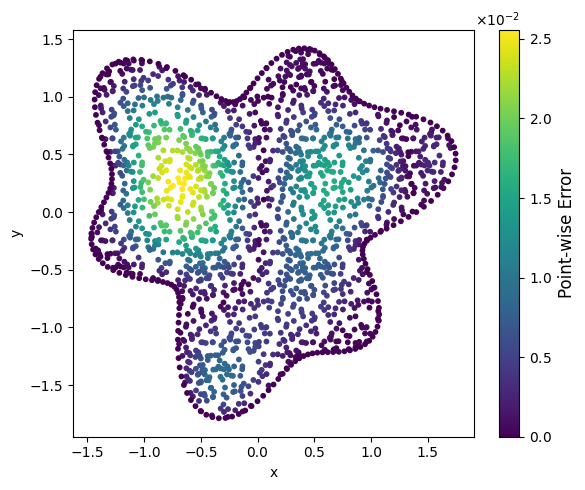

In [4]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(1, hidden_size, 1).to(device) #
Phi.initi()

Phi = Phi.double()

# # ===========================================================
u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
u0_func = lambda x, y : 1 + np.sin(x) * np.cos(y)


torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 200
N_boundary = 200
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, ptch, _ , _ = generator_points_star(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch= R_ptch, mode = mode)
X = np.vstack([X_inner, X_boundary])
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
M1 = Yin.shape[0]

#####
tau = 1e-3
T = 0.2
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

order = 3
reg = 1e-12
u_true = u_func(Y[:,0:1], Y[:,1:2],t)
scheme = "BDF2"

# # ===========================================================
if order == 0:
    U,LBDF1,LBDF2,LI = rfm_fd_pum_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg)
else:
    U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme=scheme)


error = np.abs(U - u_true)#/np.abs(u_true + 1e-6)
# print(error)
print(f'p = {order}; L infity error in u_rfmfd: {error.max().item():.3e}')
error_u = relative_l2(U, u_true)
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u:.3e}')

for i in range(Nt):
    err_time = relative_l2(U[:,i], u_true[:,i])
    print(f'Time step {i}, Relative L2 error: {err_time:.3e}')

UT = U[:,-1:].toarray().ravel()
u_true_T = u_true[:,-1:].squeeze(-1)

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UT - u_true_T), cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_pointwise.eps', bbox_inches='tight')
plt.show()

Processing patch (0,0)
Processing patch (0,1)
Processing patch (1,0)
Processing patch (1,1)
********************* TEST ERROR *********************
Nx=2, Ny=2, Jn=50, Qx_test=100, Qy_test=100
L_inf error      = 1.397310e+00
Absolute L2 error= 8.873559e-01
Relative L2 error= 6.319748e-01
Boundary L_inf errors:
bottom y=0 : 1.207022e+00
top    y=1 : 9.932126e-01
left   x=0 : 8.055679e-01
right  x=1 : 1.366541e+00


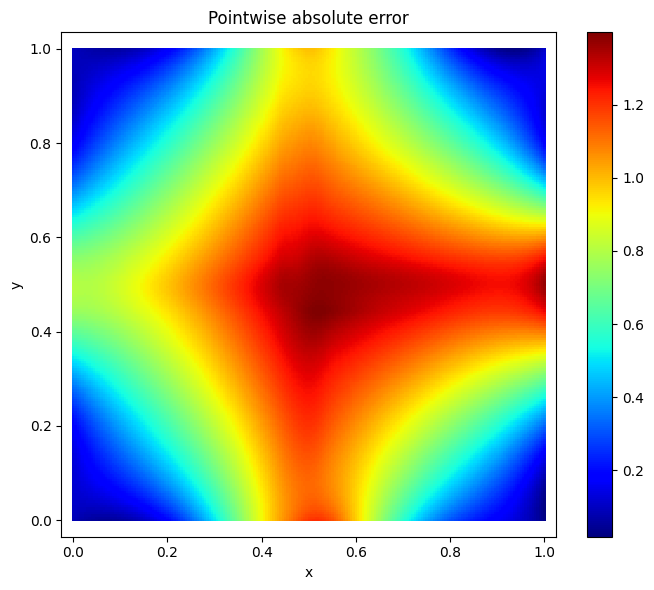

In [ ]:
# import torch
# import torch.nn as nn
# import numpy as np
# import itertools
# from scipy.sparse import lil_matrix
# from scipy.sparse.linalg import spsolve, splu
# from scipy.spatial import distance
# import matplotlib.pyplot as plt

# torch.set_default_dtype(torch.float64)
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Lx,Ly = 1, 1

# rand_mag = 1.0
# def weights_init(m):
#     if isinstance(m, (nn.Conv2d, nn.Linear)):
#         nn.init.uniform_(m.weight, a = -rand_mag, b = rand_mag)
#         nn.init.uniform_(m.bias, a = -rand_mag, b = rand_mag)
#         #nn.init.normal_(m.weight, mean=0, std=1)
#         #nn.init.normal_(m.bias, mean=0, std=1)

# class RFM_rep(nn.Module):
#     def __init__(self, in_features, Jn, x_max, x_min, t_max, t_min):
#         super(RFM_rep, self).__init__()
#         self.in_features = in_features
#         self.hidden_features = Jn
#         self.x_max = x_max
#         self.x_min = x_min
#         self.t_max = t_max
#         self.t_min = t_min
#         self.a = torch.tensor([2.0/(x_max - x_min),2.0/(t_max - t_min)],device=device)
#         self.x_0 = torch.tensor([(x_max + x_min)/2,(t_max + t_min)/2],device=device)
#         self.hidden_layer = nn.Sequential(nn.Linear(self.in_features, self.hidden_features, bias=True),nn.Tanh())
#         #print([x_min,x_max],[t_min,t_max])

#     def forward(self,x):        
#         y = self.a * (x - self.x_0)
#         y = self.hidden_layer(y)
#         dx = (x[:,:1] - (self.x_min + self.x_max)/2) / ((self.x_max - self.x_min)/2) # x 归一化后
#         dt = (x[:,1:] - (self.t_min + self.t_max)/2) / ((self.t_max - self.t_min)/2) # y 归一化后
#         dx0 = dx <= -5/4
#         dx1 = (dx <= -3/4)  & (dx > -5/4)
#         dx2 = (dx <= 3/4)  & (dx > -3/4)
#         dx3 = (dx <= 5/4)  & (dx > 3/4)
#         dx4 = dx > 5/4
#         dt0 = dt <= -5/4
#         dt1 = (dt <= -3/4)  & (dt > -5/4)
#         dt2 = (dt <= 3/4)  & (dt > -3/4)
#         dt3 = (dt <= 5/4)  & (dt > 3/4)
#         dt4 = dt > 5/4
#         yx0 = 0.0
#         yx1 = (1 + torch.sin(2*np.pi*dx) ) / 2
#         yx2 = 1.0
#         yx3 = (1 - torch.sin(2*np.pi*dx) ) / 2
#         yx4 = 0.0
        
#         yt0 = 0.0
#         yt1 = (1 + torch.sin(2*np.pi*dt) ) / 2
#         yt2 = 1.0
#         yt3 = (1 - torch.sin(2*np.pi*dt) ) / 2
#         yt4 = 0.0
        
#         # print(f"y.shape:{y.shape}, dx1.shape:{dx1.shape}, yx3.shape:{yx3.shape}")
#         if self.x_min == 0:
#             y = y*(dx0*yx0+(dx1+dx2)*yx2+dx3*yx3+dx4*yx4)
#         elif self.x_max == Lx:
#             y = y*(dx0*yx0+dx1*yx1+(dx2+dx3)*yx2+dx4*yx4)
#         else:
#             y = y*(dx0*yx0+dx1*yx1+dx2*yx2+dx3*yx3+dx4*yx4)
        
#         if self.t_min == 0:
#             y = y*(dt0*yt0+(dt1+dt2)*yt2+dt3*yt3+dt4*yt4)
#         elif self.t_max == Ly:
#             y = y*(dt0*yt0+dt1*yt1+(dt2+dt3)*yt2+dt4*yt4)
#         else:
#             y = y*(dt0*yt0+dt1*yt1+dt2*yt2+dt3*yt3+dt4*yt4)
#         return y

# def pre_define_patch_global(Nx, Ny, Jn, Qx, Qy, RFM_class, Lx=1.0, Ly=1.0):
#     """
#     Return
#     ------
#     models[k][n]
#         patch (k,n) 的 RFM 网络。
#     points[k][n]
#         patch (k,n) 的局部点，shape = (Qx+1, Qy+1, 2)。
#     patch_gids[k][n]
#         patch (k,n) 的局部点对应的全局编号，shape = (Qx+1, Qy+1)。
#     points_global
#         全局唯一点坐标，shape = ((Nx*Qx+1)*(Ny*Qy+1), 2)。
#     gid_map
#         全局编号表，shape = (Ny*Qy+1, Nx*Qx+1)，
#         gid_map[iy, ix] 表示全局编号。

#     interior_ids
#         全局内点编号。

#     boundary_ids
#         全局边界点编号。
#     """
#     Nxg = Nx * Qx
#     Nyg = Ny * Qy
#     # --------------------------------------------------
#     # 1. 全局唯一点与全局编号
#     # --------------------------------------------------
#     x_all = np.linspace(0.0, Lx, Nxg + 1)
#     y_all = np.linspace(0.0, Ly, Nyg + 1)
#     gid_map = np.arange((Nxg + 1) * (Nyg + 1)).reshape(Nyg + 1, Nxg + 1)
#     Xg, Yg = np.meshgrid(x_all, y_all, indexing="xy")
#     points_global = np.column_stack([Xg.ravel(), Yg.ravel()])
#     boundary_mask = (
#         (np.isclose(points_global[:, 0], 0.0)) |
#         (np.isclose(points_global[:, 0], Lx)) |
#         (np.isclose(points_global[:, 1], 0.0)) |
#         (np.isclose(points_global[:, 1], Ly))
#     )
#     interior_ids = np.where(~boundary_mask)[0]
#     boundary_ids = np.where(boundary_mask)[0]
#     # --------------------------------------------------
#     # 2. 按 patch 存储网络、局部点、局部全局编号
#     # --------------------------------------------------
#     models = []
#     points = []
#     patch_index = []
#     patch_bounds = []
#     for k in range(Nx):
#         row_models = []
#         row_points = []
#         row_gids = []
#         row_bounds = [] 
#         x_min = k * Lx / Nx
#         x_max = (k + 1) * Lx / Nx
#         for n in range(Ny):
#             y_min = n * Ly / Ny
#             y_max = (n + 1) * Ly / Ny
#             row_bounds.append({"x_min": x_min,
#                                 "x_max": x_max,
#                                 "y_min": y_min,
#                                 "y_max": y_max,})
#             # local RFM model
#             model = RFM_class(
#                 in_features=2,
#                 Jn=Jn,
#                 x_max=x_max,
#                 x_min=x_min,
#                 t_max=y_max,
#                 t_min=y_min,
#             ).to(device)
#             model = model.apply(weights_init)
#             model = model.double()
#             for param in model.parameters():
#                 param.requires_grad = False
#             # --------------------------------------------------
#             # patch 对应的全局编号
#             # gid_map 的顺序是 [iy, ix]
#             # 为了匹配 points[k][n] 的 shape = (Qx+1, Qy+1, 2)，这里转置
#             # --------------------------------------------------
#             ix0, ix1 = k * Qx, (k + 1) * Qx
#             iy0, iy1 = n * Qy, (n + 1) * Qy
#             gids = gid_map[iy0:iy1 + 1, ix0:ix1 + 1].T
#             # gids.shape = (Qx+1, Qy+1)
#             # 直接从全局点取局部点，避免重复生成坐标
#             pts_np = points_global[gids.reshape(-1)].reshape(Qx + 1, Qy + 1, 2)
#             pts = torch.tensor(pts_np, dtype=torch.float64, requires_grad=True).to(device)
#             row_models.append(model)
#             row_points.append(pts)
#             row_gids.append(gids)
#         models.append(row_models)   # models[k][n]     : model 
#         points.append(row_points)   # points[k][n]     : grid in patch
#         patch_index.append(row_gids) # patch_gids[k][n] : index of grid in patch
#         patch_bounds.append(row_bounds)
#     return models, points, patch_index, points_global, patch_bounds,interior_ids, boundary_ids

# Nx = Ny = 2
# Jn = 50
# Qx = Qy = 50
# models, points, patch_index, points_global, patch_bounds, interior_ids, boundary_ids = pre_define_patch_global(Nx, Ny, Jn, Qx, Qy, RFM_rep, Lx=1.0, Ly=1.0)

# # i = j = 1
# # print("(i=1,j=1) patch's grid id is", patch_index[i][j].flatten())
# # patch_interior_global = np.intersect1d(patch_index[i][j].flatten(), interior_ids)
# # patch_boundary_global = np.intersect1d(patch_index[i][j].flatten(), boundary_ids)
# # print("(i=1,j=1) patch's interior id is", patch_interior_global)
# # print("(i=1,j=1) patch's boundary id is", patch_boundary_global)
# # print("points' shape is", points_global.shape)

# # u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
# # f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
# # g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
# # u0_func = lambda x, y : 1 + np.sin(x) * np.cos(y)

# u_func = lambda x, y: 1 + np.sin(x) * np.cos(y)
# f_func = lambda x, y: np.sin(x) * np.cos(y)
# g_func = lambda x, y: 1 + np.sin(x) * np.cos(y)


# def cal_matrix(models, points_global, patch_index, interior_ids, boundary_ids, Nx, Ny, Jn, Qx, Qy, device=device):
#     """
#     计算每个 patch 的 RFM 基函数值及 Laplacian

#     Returns:
#         A: 全局矩阵 (M, Nx*Ny*Jn)
#         patch_lap: list of (Mk_in, Jn) 每个 patch 内点 Laplacian
#         patch_phi: list of (Mk, Jn) 每个 patch 所有点的 phi
#     """
#     M = points_global.shape[0]
#     A = np.zeros((M, Nx*Ny*Jn))
#     patch_lap = [[None for _ in range(Ny)] for _ in range(Nx)]
#     patch_phi = [[None for _ in range(Ny)] for _ in range(Nx)]
#     for k in range(Nx):
#         for n in range(Ny):
#             print(f"Processing patch ({k},{n})")
#             idx_Yj = patch_index[k][n].flatten()          # patch 全局索引
#             Yj_np = points_global[idx_Yj]                 # shape (Mk,2)
#             Mk = len(idx_Yj)
#             # 局部内点行号
#             local_in = np.where(np.isin(idx_Yj, interior_ids))[0]
#             global_in = idx_Yj[local_in]
#             local_b = np.where(np.isin(idx_Yj, boundary_ids))[0]
#             global_b = idx_Yj[local_b]
#             # 转 torch 张量
#             Yj = torch.as_tensor(Yj_np, dtype=torch.float64, device=device)
#             Yj = Yj.clone().detach().requires_grad_(True)
#             # 基函数
#             out = models[k][n](Yj)       # (Mk, Jn)
#             out_np = out.detach().cpu().numpy()
#             patch_phi[k][n] = out_np
#             # 计算梯度和 Laplacian（只在内点）
#             lap_mat = np.zeros((len(local_in), Jn))
#             for j in range(Jn):
#                 phi_j = out[:, j]
#                 # 一阶导
#                 grad_phi = torch.autograd.grad(
#                     outputs=phi_j,
#                     inputs=Yj,
#                     grad_outputs=torch.ones_like(phi_j),
#                     create_graph=True,
#                     retain_graph=True
#                 )[0]  # (Mk, 2)
#                 # 二阶导数
#                 g2_x = torch.autograd.grad(
#                     outputs=grad_phi[:, 0],
#                     inputs=Yj,
#                     grad_outputs=torch.ones_like(grad_phi[:,0]),
#                     create_graph=True,
#                     retain_graph=True
#                 )[0][:, 0]
#                 g2_y = torch.autograd.grad(
#                     outputs=grad_phi[:, 1],
#                     inputs=Yj,
#                     grad_outputs=torch.ones_like(grad_phi[:,1]),
#                     create_graph=True,
#                     retain_graph=True
#                 )[0][:, 1]
#                 # 只保留内点
#                 lap_mat[:, j] = -(g2_x[local_in] + g2_y[local_in]).detach().cpu().numpy()

#             patch_lap[k][n] = lap_mat
#             col0 = ( k*Ny + n) * Jn
#             col1 = col0 + Jn
#             A[global_in,col0:col1] += lap_mat
#             A[global_b,col0:col1] += out_np[local_b, :]
#     return A, patch_lap, patch_phi

# def build_RHS(points_global, interior_ids, boundary_ids, f_func, g_func):
#     M = points_global.shape[0]
#     RHS = np.zeros((M, 1), dtype=np.float64)

#     Xin = points_global[interior_ids]
#     Xb = points_global[boundary_ids]

#     RHS[interior_ids, 0:1] = f_func(
#         Xin[:, 0:1],
#         Xin[:, 1:2]
#     )
#     RHS[boundary_ids, 0:1] = g_func(
#         Xb[:, 0:1],
#         Xb[:, 1:2]
#     )
#     return RHS

# u_func = lambda x, y: 1 + np.sin(x) * np.cos(y)
# f_func = lambda x, y: 2 * np.sin(x) * np.cos(y)
# g_func = lambda x, y: 1 + np.sin(x) * np.cos(y)

# A, patch_lap, patch_phi = cal_matrix(
#     models, points_global, patch_index,
#     interior_ids, boundary_ids,
#     Nx, Ny, Jn, Qx, Qy
# )

# RHS = build_RHS(
#     points_global,
#     interior_ids,
#     boundary_ids,
#     f_func,
#     g_func
# )
# M = points_global.shape[0]
# max_value = 10.0
# for i in range(M):
#     if np.abs(A[i,:].max())==0:
#         print("error line : ",i)
#         continue
#     ratio = max_value/np.abs(A[i,:]).max()
#     A[i,:] = A[i,:]*ratio
#     RHS[i] = RHS[i]*ratio

# w = np.linalg.lstsq(A,RHS)[0]


# def evaluate_rfm_solution_(models,patch_bounds,Xtest,w,Nx,Ny,Jn,device=device,use_support_filter=True,):
#     """
#     Evaluate RFM-PU solution on test points.
#     The numerical solution is
#         u_h(x) = sum_{k,n} Phi_{k,n}(x) @ w_{k,n}.
#     Since RFM_rep.forward already contains the local POU/window function,
#     we must sum over all overlapping patches.
#     Parameters
#     ----------
#     models : list
#         models[k][n] is the RFM model on patch (k,n).
#     patch_bounds : list
#         patch_bounds[k][n] contains x_min, x_max, y_min, y_max.
#     Xtest : ndarray, shape (Ntest, 2)
#         Test points.
#     w : ndarray, shape (Nx*Ny*Jn, 1)
#     use_support_filter : bool
#         If True, only evaluate a patch on points inside its enlarged support.
#         If False, evaluate all patches on all points.
#     Returns
#     -------
#     uh : ndarray, shape (Ntest, 1)
#     Atest : ndarray, shape (Ntest, Nx*Ny*Jn)
#     """
#     Xtest = np.asarray(Xtest, dtype=np.float64)
#     Ntest = Xtest.shape[0]

#     if w.ndim == 1:
#         w = w[:, None]

#     Atest = np.zeros((Ntest, Nx * Ny * Jn), dtype=np.float64)

#     for k in range(Nx):
#         for n in range(Ny):
#             b = patch_bounds[k][n]
#             x0, x1 = b["x_min"], b["x_max"]
#             y0, y1 = b["y_min"], b["y_max"]
#             col0 = (k * Ny + n) * Jn
#             col1 = col0 + Jn
#             if use_support_filter:
#                 hx = x1 - x0
#                 hy = y1 - y0
#                 x0_ext = x0 - hx / 8.0
#                 x1_ext = x1 + hx / 8.0
#                 y0_ext = y0 - hy / 8.0
#                 y1_ext = y1 + hy / 8.0
#                 mask = (
#                     (Xtest[:, 0] >= x0_ext) &
#                     (Xtest[:, 0] <= x1_ext) &
#                     (Xtest[:, 1] >= y0_ext) &
#                     (Xtest[:, 1] <= y1_ext)
#                 )
#                 idx = np.where(mask)[0]
#                 if len(idx) == 0:
#                     continue
#                 X_patch_np = Xtest[idx]
#             else:
#                 idx = np.arange(Ntest)
#                 X_patch_np = Xtest
#             X_patch = torch.as_tensor(
#                 X_patch_np,
#                 dtype=torch.float64,
#                 device=device
#             )
#             with torch.no_grad():
#                 Phi = models[k][n](X_patch).detach().cpu().numpy()
#             # 注意这里是填测试矩阵对应行
#             Atest[idx, col0:col1] = Phi
#     uh = Atest @ w
#     return uh, Atest

# def test_rfm_solution(models,w,u_func,Nx,Ny,Jn,Qx_test=300,Qy_test=300,Lx=1.0,Ly=1.0,device=device,plot=True,):
#     """
#     Test RFM-PU solution on a refined global grid.
#     Qx_test, Qy_test:
#     每个 patch 方向上的测试细分数。
#     全局测试网格大小为:
#     (Nx*Qx_test + 1) x (Ny*Qy_test + 1)
#     """
#     Nxg_test = Nx * Qx_test
#     Nyg_test = Ny * Qy_test
#     x_test = np.linspace(0.0, Lx, Nxg_test + 1)
#     y_test = np.linspace(0.0, Ly, Nyg_test + 1)
#     Xg, Yg = np.meshgrid(x_test, y_test, indexing="xy")
#     Xtest = np.column_stack([Xg.ravel(), Yg.ravel()])   # (Ntest, 2)
#     # numerical solution
#     uh,_ = evaluate_rfm_solution_(models,patch_bounds,Xtest,w,Nx,Ny,Jn,device = device)
#     # exact solution
#     u_exact = u_func(Xtest[:, 0:1],Xtest[:, 1:2])
#     err = uh - u_exact
#     abs_err = np.abs(err)

#     L_inf = np.max(abs_err)
#     L2_abs = np.sqrt(np.mean(err**2))
#     L2_rel = np.linalg.norm(err) / np.linalg.norm(u_exact)

#     print("********************* TEST ERROR *********************")
#     print(f"Nx={Nx}, Ny={Ny}, Jn={Jn}, Qx_test={Qx_test}, Qy_test={Qy_test}")
#     print(f"L_inf error      = {L_inf:.6e}")
#     print(f"Absolute L2 error= {L2_abs:.6e}")
#     print(f"Relative L2 error= {L2_rel:.6e}")

#     # boundary error
#     uh_grid = uh.reshape(Nyg_test + 1, Nxg_test + 1)
#     ue_grid = u_exact.reshape(Nyg_test + 1, Nxg_test + 1)
#     e_grid = np.abs(uh_grid - ue_grid)

#     bottom_err = np.max(e_grid[0, :])
#     top_err = np.max(e_grid[-1, :])
#     left_err = np.max(e_grid[:, 0])
#     right_err = np.max(e_grid[:, -1])

#     print("Boundary L_inf errors:")
#     print(f"bottom y=0 : {bottom_err:.6e}")
#     print(f"top    y=1 : {top_err:.6e}")
#     print(f"left   x=0 : {left_err:.6e}")
#     print(f"right  x=1 : {right_err:.6e}")

#     if plot:
#         plt.figure(figsize=(7, 6))
#         plt.pcolormesh(Xg, Yg, e_grid, shading="auto", cmap="jet")
#         plt.colorbar()
#         plt.xlabel("x")
#         plt.ylabel("y")
#         plt.title("Pointwise absolute error")
#         plt.axis("equal")
#         plt.tight_layout()
#         plt.show()

#     return L_inf, L2_abs, L2_rel, e_grid, uh_grid, ue_grid

# L_inf, L2_abs, L2_rel, e_grid, uh_grid, ue_grid = test_rfm_solution( models=models,w=w,u_func=u_func,Nx=Nx,Ny=Ny,Jn=Jn, Qx_test=100,Qy_test=100, Lx=1.0,Ly=1.0, plot=True,)

In [ ]:
# # ===========================================================
u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
u0_func = lambda x, y : 1 + np.sin(x) * np.cos(y)

# 画收敛阶段图

Run Q=1, N_local_per_patch=20
X.shape 323
h = 2.274e-01, L2 error = 8.752e-02, 
Run Q=2, N_local_per_patch=50
X.shape 782
h = 1.207e-01, L2 error = 6.848e-02, 
Run Q=3, N_local_per_patch=100
X.shape 1571
h = 1.091e-01, L2 error = 6.525e-02, 
Run Q=4, N_local_per_patch=150
X.shape 2339
h = 7.625e-02, L2 error = 6.495e-02, 
Run Q=5, N_local_per_patch=250
X.shape 3898
h = 6.671e-02, L2 error = 6.381e-02, 
slope = 0.254516, bias = 0.912852


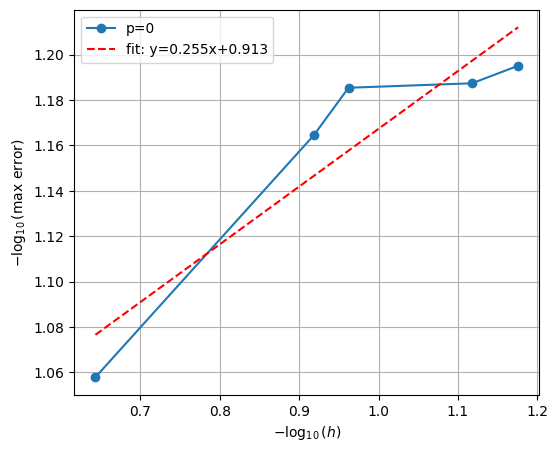

In [6]:
key = 100
np.random.seed(key)

NN = [20,50,100,150,250]
H = np.zeros((5,len(NN)))
E = np.zeros((5,len(NN)))
tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)
scheme = "BDF2"
RR = [1e-12,1e-12,1e-12,1e-12,1e-12]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    overlap = 0.2
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, overlap = overlap, mode = mode)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 0
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,_,_,_ = rfm_fd_pum_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg)
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=20
X.shape 323
cond(cond_L) = 32592023792.08778
cond(LI) =  1.0000007298690303
cond(LBDF2) = 65173115.94143714
h = 2.274e-01, L2 error = 7.178e-02, 
Run Q=2, N_local_per_patch=50
X.shape 782
cond(cond_L) = 89876059821.07776
cond(LI) =  1.0000025017885108
cond(LBDF2) = 179672311.72354296
h = 1.207e-01, L2 error = 6.543e-02, 
Run Q=3, N_local_per_patch=100
X.shape 1571
cond(cond_L) = 97480762652.56729
cond(LI) =  1.0000025119759652
cond(LBDF2) = 194769506.40765995
h = 1.091e-01, L2 error = 6.238e-02, 
Run Q=4, N_local_per_patch=150
X.shape 2339
cond(cond_L) = 133149663308.65958
cond(LI) =  1.0000033697794488
cond(LBDF2) = 265889329.05837464
h = 7.625e-02, L2 error = 6.166e-02, 
Run Q=5, N_local_per_patch=250
X.shape 3898
cond(cond_L) = 168364788841.5956
cond(LI) =  1.0000039978563802
cond(LBDF2) = 335827700.6095255
h = 6.671e-02, L2 error = 6.093e-02, 
slope = 0.134884, bias = 1.061715


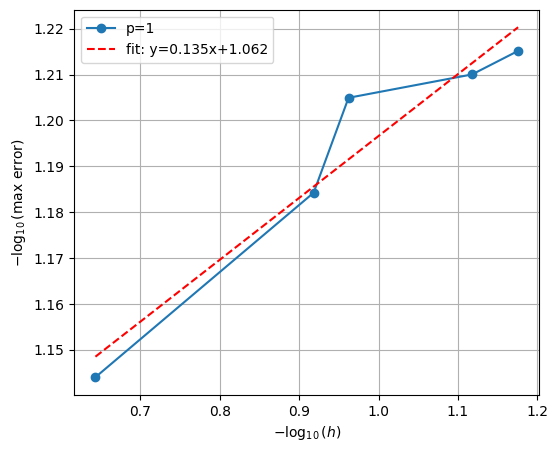

In [7]:
key = 100
np.random.seed(key)
NN = [20,50,100,150,250]
tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)
scheme = "BDF2"
RR = [1e-12,1e-12,1e-12,1e-12,1e-12]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    overlap = 0.2
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, overlap = overlap, mode = mode)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 1
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,_,_,_ = rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=20
X.shape 323
cond(cond_L) = 75849177669.35829
cond(LI) =  1.0000007378891531
cond(LBDF2) = 151540168.5525121
h = 2.274e-01, L2 error = 4.347e-02, 
Run Q=2, N_local_per_patch=50
X.shape 782
cond(cond_L) = 325937882982.5194
cond(LI) =  1.0000024977126885
cond(LBDF2) = 650734873.8199835
h = 1.207e-01, L2 error = 2.803e-02, 
Run Q=3, N_local_per_patch=100
X.shape 1571
cond(cond_L) = 373905514868.2575
cond(LI) =  1.000002509373225
cond(LBDF2) = 745346572.6083099
h = 1.091e-01, L2 error = 2.499e-02, 
Run Q=4, N_local_per_patch=150
X.shape 2339
cond(cond_L) = 554454515227.2329
cond(LI) =  1.0000033681612572
cond(LBDF2) = 1103409349.2378514
h = 7.625e-02, L2 error = 2.183e-02, 
Run Q=5, N_local_per_patch=250
X.shape 3898
cond(cond_L) = 800853571151.9657
cond(LI) =  1.0000039977972002
cond(LBDF2) = 1588748580.933358
h = 6.671e-02, L2 error = 1.930e-02, 
slope = 0.646029, bias = 0.955943


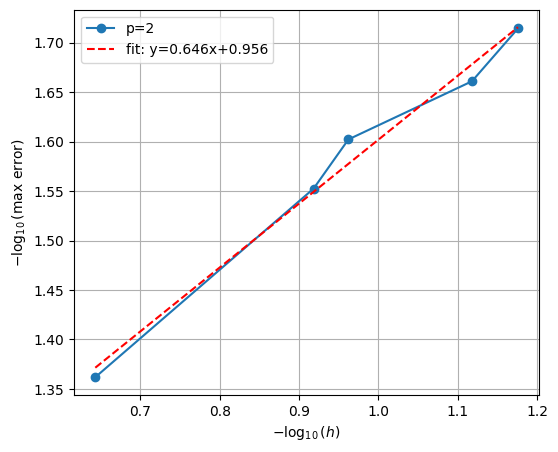

In [8]:
key = 100
np.random.seed(key)

NN = [20,50,100,150,250]
BC = [20,50,100,150,250]

tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

RR = [1e-12,1e-12,1e-12,1e-12,1e-12]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = BC[qi]
    overlap = 0.2
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, overlap = overlap, mode = mode)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 2
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,_,_,_ = rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label= f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=20
X.shape 323
cond(cond_L) = 142152270738.32767
cond(LI) =  1.0000007340590595
cond(LBDF2) = 288087021.0309396
h = 2.274e-01, L2 error = 1.626e-02, 
Run Q=2, N_local_per_patch=50
X.shape 782
cond(cond_L) = 1298116775370.4343
cond(LI) =  1.0000024859118883
cond(LBDF2) = 2587908183.133176
h = 1.207e-01, L2 error = 8.375e-03, 
Run Q=3, N_local_per_patch=100
X.shape 1571
cond(cond_L) = 1291047449327.6338
cond(LI) =  1.0000025023326935
cond(LBDF2) = 2572729819.9568706
h = 1.091e-01, L2 error = 7.686e-03, 
Run Q=4, N_local_per_patch=150
X.shape 2789
cond(cond_L) = 3164761924479.366
cond(LI) =  1.0000067434232771
cond(LBDF2) = 6298427539.610889
h = 7.057e-02, L2 error = 7.431e-03, 
Run Q=5, N_local_per_patch=250
X.shape 4848
cond(cond_L) = 5044742455229.93
cond(LI) =  1.000009708537241
cond(LBDF2) = 10002470248.800995
h = 6.671e-02, L2 error = 7.311e-03, 
slope = 0.624850, bias = 1.442821


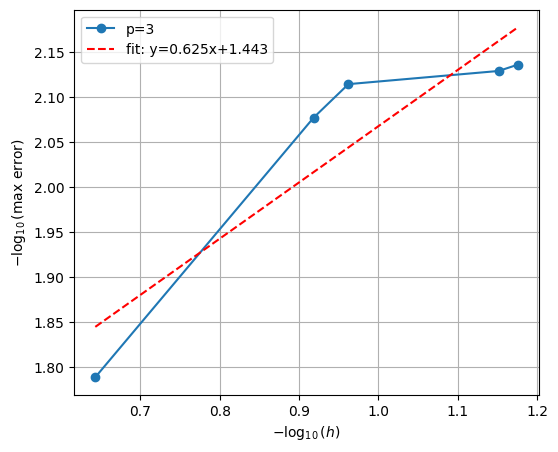

In [9]:
key = 100
np.random.seed(key)

NN = [20,50,100,150,250]
BC = [20,50,100,600,1200]

tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

RR = [1e-12,1e-12,1e-12,1e-12,1e-12]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = BC[qi]
    overlap = 0.2
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, overlap = overlap, mode = mode)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 3
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,_,_,_ = rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


In [10]:
# key = 100
# np.random.seed(key)

# NN = [250]

# BC = [1200]

# tau = 1e-3
# T = 0.2 
# Nt = int(T/tau) + 1
# t =  np.linspace(0,T,Nt)

# RR = [1e-11,1e-12,1e-12,1e-12,1e-12]

# for qi, n_local in enumerate(NN):
#     print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
#     N_patch_grid = 5
#     N_local_per_patch = n_local
#     N_boundary = BC[qi]
#     overlap = 0.2
#     mode = "c-rbf-pum"
#     # generate points
#     X_inner, X_boundary, _, _ ,_ = generator_points_star(
#     N_patch_grid, N_local_per_patch, N_boundary, overlap = overlap, mode = mode)

#     # assemble X,Y
#     X = np.vstack([X_inner, X_boundary])
#     Yin = X_inner
#     Yb = X_boundary
#     print(f"X.shape",X.shape[0])
#     Y = np.vstack([Yin, Yb])
#     order = 3
#     h = fill_distance(X)
#     H[order,qi] = h
#     reg = RR[qi]
#     u_true = u_func(Y[:,0:1], Y[:,1:2],t)
#     U,_,_,_ = rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
#     error = np.max(np.abs(U - u_true))
#     e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
#     E[order,qi] = e
#     print(f'h = {h:.3e}, L2 error = {e:.3e}, ')

Run Q=1, N_local_per_patch=20
X.shape 343
cond(cond_L) = 1933709483712.83
cond(LI) =  1.0000007427800812
cond(LBDF2) = 3477809877.9825954
h = 2.274e-01, L2 error = 4.562e-03, 
Run Q=2, N_local_per_patch=50
X.shape 797
cond(cond_L) = 7851874078237.376
cond(LI) =  1.000000972936553
cond(LBDF2) = 15442963854.338182
h = 1.186e-01, L2 error = 4.226e-03, 
Run Q=3, N_local_per_patch=100
X.shape 1631
cond(cond_L) = 23694948763773.336
cond(LI) =  1.0000022888749134
cond(LBDF2) = 45700373614.41603
h = 9.811e-02, L2 error = 3.616e-03, 
Run Q=4, N_local_per_patch=150
X.shape 2839
cond(cond_L) = 31924951179442.0
cond(LI) =  1.0000037167071238
cond(LBDF2) = 60966404650.21358
h = 7.057e-02, L2 error = 3.518e-03, 
Run Q=5, N_local_per_patch=250
X.shape 4898
cond(cond_L) = 188151283602676.97
cond(LI) =  1.000021458940376
cond(LBDF2) = 349787965496.8554
h = 6.671e-02, L2 error = 3.421e-03, 
slope = 0.240950, bias = 2.178902


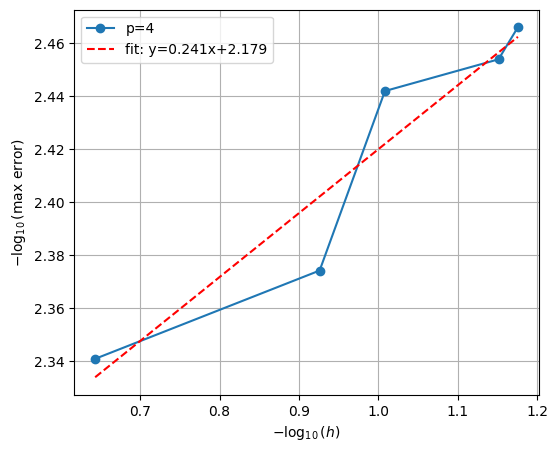

In [11]:
key = 100
np.random.seed(key)

NN = [20, 50, 100, 150, 250]
BC = [40, 65, 160, 650, 1250]
tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

RR = [1e-12,1e-12,1e-12,1e-12,1e-12]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = BC[qi]
    overlap = 0.2
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, overlap = overlap, mode = mode)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 4
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,_,_,_ = rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


In [12]:
# key = 100
# np.random.seed(key)

# NN = [20]
# BC = [40]
# tau = 1e-3
# T = 0.2 
# Nt = int(T/tau) + 1
# t =  np.linspace(0,T,Nt)

# RR = [1e-12,1e-12,1e-12,1e-12,1e-12]

# for qi, n_local in enumerate(NN):
#     print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
#     N_patch_grid = 5
#     N_local_per_patch = n_local
#     N_boundary = BC[qi]
#     overlap = 0.2
#     mode = "c-rbf-pum"
#     # generate points
#     X_inner, X_boundary, _, _ ,_ = generator_points_star(
#     N_patch_grid, N_local_per_patch, N_boundary, overlap = overlap, mode = mode)

#     # assemble X,Y
#     X = np.vstack([X_inner, X_boundary])
#     Yin = X_inner
#     Yb = X_boundary
#     print(f"X.shape",X.shape[0])
#     Y = np.vstack([Yin, Yb])
#     order = 4
#     h = fill_distance(X)
#     H[order,qi] = h
#     reg = RR[qi]
#     u_true = u_func(Y[:,0:1], Y[:,1:2],t)
#     U,_,_,_ = rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
#     error = np.max(np.abs(U - u_true))
#     e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
#     E[order,qi] = e
#     print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


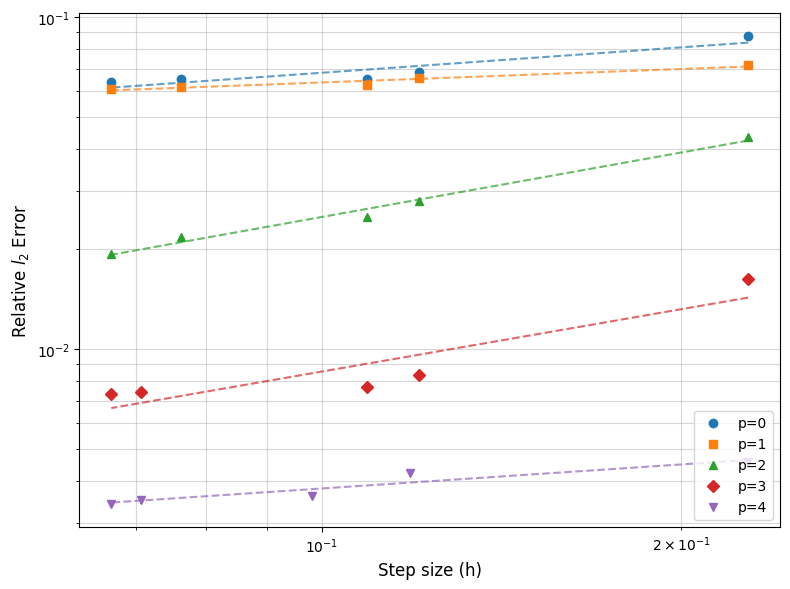

In [13]:
markers = ['o', 's', '^', 'D', 'v']  
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = ['p=0', 'p=1', 'p=2', 'p=3','p=4']
plt.figure(figsize=(8, 6))

for i in range(5):
    h = H[i, :]
    e = E[i, :]
    log_h = np.log(h)
    log_e = np.log(e)
    slope, intercept = np.polyfit(log_h, log_e, 1)
    fit_e = np.exp(intercept) * h**slope
    plt.loglog(h, e, markers[i], color=colors[i], label=f'{labels[i]}')
    plt.loglog(h, fit_e, linestyle='--', color=colors[i], alpha=0.7)
    # plt.plot(h, e, marker=markers[i], color=colors[i], linestyle='-', label=f'{labels[i]}')

plt.xlabel('Step size (h)', fontsize=12)
plt.ylabel('Relative $l_2$ Error', fontsize=12)
# plt.title('Convergence Study: Least Squares Fit', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('./result/heat_rfmfd_pu_p=0123_convergence_scatter.eps', bbox_inches='tight')
plt.show()

$Operator learning$

In [5]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import spsolve
from scipy.linalg import cholesky, solve_triangular

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)


def build_wls_solver(A, reg=1e-12):
    """
    Weighted least squares QR solver for repeated RHS.

    Solve
        min_X || W (A X - B) ||_2^2 + reg ||X||_2^2

    Parameters
    ----------
    A : scipy sparse matrix, shape (M,N)
    reg : float
        Tikhonov regularization


    Returns
    -------
    solve : callable
        solve(RHS) -> (N,K)
    """
    if not sp.isspmatrix(A):
        raise TypeError("A must be scipy sparse matrix")

    A = A.tocsr()
    M, N = A.shape

    # ==================================================
    # row weights
    # ==================================================
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 10.0 / (row_max + 1e-12)

    # ==================================================
    # weighted sparse matrix
    # ==================================================
    Aw = A.multiply(w[:, None])

    # ==================================================
    # Tikhonov augmentation
    # [Aw]
    # [sqrt(reg) I]
    # ==================================================
    if reg > 0:
        Ireg = sp.eye(N, format="csr") * np.sqrt(reg)
        Aw_aug = sp.vstack([Aw, Ireg], format="csr")
    else:
        Aw_aug = Aw

    # ==================================================
    # dense QR factorization
    # ==================================================
    Aw_dense = Aw_aug.toarray()
    Q, R = np.linalg.qr(Aw_dense, mode="reduced")

    def solve(RHS):
        RHS = np.asarray(RHS, dtype=np.float64)

        if RHS.ndim == 1:
            RHS = RHS[:, None]

        # weighted RHS
        Bw = w[:, None] * RHS

        # augment zero block for regularization
        if reg > 0:
            Bw = np.vstack([Bw, np.zeros((N, RHS.shape[1]))])

        # QR solve
        y = Q.T @ Bw
        X = solve_triangular(R, y, lower=False)

        return X

    return solve


def test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, u0_func,
                Yin, Yb, t, tau,
                scheme="BDF2"):
    """
    Multi-batch heat solver using unified WLS (row-max weighted least squares).

    Returns
    -------
    U : ndarray, shape (n_batch, M, NT)
    """

    # --------------------------------------------------
    # geometry
    # --------------------------------------------------
    Y = np.concatenate([Yin, Yb], axis=0)
    M = Y.shape[0]
    M2 = Yb.shape[0]
    M1 = M - M2
    NT = t.shape[0]

    # --------------------------------------------------
    # data
    # --------------------------------------------------
    f_val = f_func(Yin[:, 0:1], Yin[:, 1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:, 0:1], Yb[:, 1:2], t) if callable(g_func) else g_func

    u0 = u0_func(Y[:, 0:1], Y[:, 1:2]) if callable(u0_func) else u0_func
    u0 = np.asarray(u0, dtype=np.float64)

    # --------------------------------------------------
    # batch handling
    # --------------------------------------------------
    if u0.ndim == 1:
        u0 = u0[:, None]

    n_batch = u0.shape[1]

    solve_LBDF1 = build_wls_solver(LBDF1, reg=1e-12)
    solve_LBDF2 = build_wls_solver(LBDF2, reg=1e-12)
    solve_LI    = build_wls_solver(LI, reg=1e-12)

    # --------------------------------------------------
    # initial solve (LI)
    # --------------------------------------------------
    alpha_0 = solve_LI(u0)

    # --------------------------------------------------
    # storage
    # --------------------------------------------------
    U = np.zeros((n_batch, M, NT), dtype=np.float64)
    U[:, :, 0] = u0.T
    U[:, M1:, :] = g_val[None, :, :]

    reg = 1e-12

    # ==================================================
    # BDF1
    # ==================================================
    if scheme == "BDF1":

        for i in range(0, NT - 1):

            rhs_int = LI @ alpha_0
            if rhs_int.ndim == 1:
                rhs_int = rhs_int[:, None]

            rhs = rhs_int[:M1, :] + tau * f_val[:, i + 1:i + 2]

            RHS = np.vstack([
                rhs,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_1, _ = solve_LBDF1(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_1).T

            alpha_0 = alpha_1

        return U
    # ==================================================
    # BDF2
    # ==================================================
    elif scheme == "BDF2":

        # -----------------------------
        # step 1: initial BDF1 step
        # -----------------------------
        rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]

        RHS = np.vstack([
            rhs_int,
            np.repeat(g_val[:, 1:2], n_batch, axis=1)
        ])

        alpha_1 = solve_LBDF1(RHS)

        U[:, :M1, 1] = (LI[:M1, :] @ alpha_1).T

        # -----------------------------
        # BDF2 time loop
        # -----------------------------
        for i in range(1, NT - 1):

            rhs_int = (
                LI[:M1, :] @ (4 * alpha_1 - alpha_0)
                + 2 * tau * f_val[:, i + 1:i + 2]
            )

            RHS = np.vstack([
                rhs_int,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_2 = solve_LBDF2(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_2).T
            U[:, M1:, i + 1] = g_val[:, i + 1]

            alpha_0 = alpha_1
            alpha_1 = alpha_2

        return U

    else:
        raise ValueError("Unsupported scheme. Use 'BDF1' or 'BDF2'.")
    

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(0.9225)**2 * x**2) # operator
        output = self.input_layer(x)
        output = torch.sin(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.uniform_(m.bias, -0, 0)


In [6]:
### rewrite the solver for weighted QR
def rfm_fd_pum_poly_solve_heat_QR(
        ptch, X, Yin, Yb, t, tau,
        f_func, g_func, u0_func,
        Phi, reg, order,
        scheme="BDF2"
):
    """
    PUM-RFM-FD heat solver with pre-factorized weighted least squares.

    Returns
    -------
    U      : (M, NT)
    LBDF1  : sparse matrix
    LBDF2  : sparse matrix
    LI     : sparse matrix
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    Nc = patch_C.shape[0]
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    W_matrix = shepard_weights(Y, patch_C, patch_R)  # M x Nc
    # Construct sparse L matrix
    L = lil_matrix((M, N)) # laplace matrix
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))
    LBDF2 = lil_matrix((M, N))

    # Construct RHS
    RHS = np.zeros((M,1))
    # Precompute RHS
    f_val = f_func(Yin[:,0:1], Yin[:,1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:,0:1], Yb[:,1:2], t) if callable(g_func) else g_func
    u0 = u0_func(Y[:,0:1], Y[:,1:2]) if callable(u0_func) else u0_func[:, None]

    # --------------------------
    # 预处理邻域索引（vectorized）
    # --------------------------
    dist_XC = cdist(X, patch_C)      # (N, Nc)
    dist_Y1C = cdist(Yin, patch_C)   # (M1, Nc)
    dist_Y2C = cdist(Yb, patch_C)    # (M2, Nc)
    dist_YC = cdist(Y, patch_C)      # (M, Nc)

    idx_X_list = [np.where(dist_XC[:, i] <= patch_R[i] + 1e-12)[0] for i in range(Nc)]
    idx_Yin_list = [np.where(dist_Y1C[:, i] <= patch_R[i] + 1e-12)[0] for i in range(Nc)]
    idx_Yb_list = [np.where(dist_Y2C[:, i] <= patch_R[i] + 1e-12)[0] for i in range(Nc)]
    idx_Y_list = [np.where(dist_YC[:, i] <= patch_R[i] + 1e-12)[0] for i in range(Nc)]
    # --------------------------------------------------
    for i in range(Nc):
        idx_X = idx_X_list[i]
        idx_Yin = idx_Yin_list[i]
        idx_Yb = idx_Yb_list[i]
        idx_Y = idx_Y_list[i]

        Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
        Yk_in,Yk_b = Yin[idx_Yin],Yb[idx_Yb]
        Yk = np.concatenate([Yk_in,Yk_b], axis = 0)
        nj = idx_X.shape[0]
        print(f"Patch {i+1}/{Nc}: nj={nj}, Mk={Mk}, Mk_1={Mk_1}")
        RHS_lap = np.zeros((nj+Norder,Mk_1)) # only need interior points
        RHS_ide = np.ones((nj+Norder,Mk))
        AP = np.zeros((nj+Norder,nj+Norder))
        P = np.ones((nj,Norder))

        Z = X[idx_X,:] # (nj,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (nj,nj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (nj,nj)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_YX, lap_phi, _  = laplacian_phi_wrt_y(Phi, Yk, Z, eps=1e-8) # (Mk,nj) # if not Yk, storage will be too large.
        
        # AP
        P = poly2D(Z, order)  # (nj,Norder)
        AP[:nj,:] = np.concatenate([Phi_jj,P], axis = 1) # (nj,nj+Norder)
        AP[nj:,:-Norder] = P.T # (Norder,nj)
        ## --- RHS_lap(Yin), RHS_ide(Y)
        lap_p = laplacian_poly2D(order,Yk_in) # (Norder, Mk_1)
        p_y = poly2D(Yk, order).T       # (Mk,Norder).T = (Norder,Mk)
        lap_phi = lap_phi[:Mk_1,:]      # (Mk,nj) --> (Mk_1,nj)
        RHS_lap[:nj,:] = lap_phi.T      # (nj, Mk_1), Yk_in
        RHS_lap[nj:,:] = lap_p          # (Norder, Mk_1)
        RHS_ide[:nj,:] = phi_YX.T       # (Mk,nj).T 
        RHS_ide[nj:,:] = p_y            # (Norder, Mk)
        # --- w_lap, w_ide
        AP = AP + reg * np.eye(nj + Norder)
        LU = lu_factor(AP)
        w_ide = lu_solve(LU, RHS_ide)   # (nj + Norder, Mk)
        w_lap = lu_solve(LU, RHS_lap)   # (nj + Norder, Mk_1)
        # --- Shepard weight
        win = W_matrix[idx_Yin,i][None, :]    # (1, Mk_1)
        Laplace = win * w_lap[:nj,:Mk_1]      # (nj, Mk_1)
        # I = win * w_ide[:nj,:Mk_1]          # (nj, Mk_1)

        # --- boundary condtion
        wbc = W_matrix[M1+idx_Yb,i][None, :]  # (1, Mk_2)
        Op_bc = wbc * w_ide[:nj,Mk_1:]        # (nj, Mk_2)

        # --- LI 
        wvec = W_matrix[idx_Y, i][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]             # (nj,Mk)

        # --- Derivative Matrix
        L[np.ix_(idx_Yin, idx_X)] += Laplace.T
        L[np.ix_(M1+idx_Yb, idx_X)] += Op_bc.T
        LI[np.ix_(idx_Y,idx_X)] += IDE.T
    

    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (M,1)
    U[M1:,:] = g_val

    L = L.tocsr()
    # lam_max = max(abs(eigs(L, k=1, which='LM', return_eigenvectors=False)))
    # print("spectral radius(Laplace) ~", lam_max)
    LI = LI.tocsr()
    if M == N:
        cond_L = np.linalg.cond(L.todense())
        print("cond(cond_L) =", cond_L)
        cond_LI = np.linalg.cond(LI.todense())
        print("cond(LI) = ", cond_LI)

    LBDF1 = (LI - tau * L)
    LBDF1[M1:,:] = LI[M1:,:]
    LBDF2 = (3 * LI - 2 * tau * L)
    LBDF2[M1:,:] = LI[M1:,:]
    # --------------------------------------------------
    # WLS pre-factorization
    # --------------------------------------------------
    solve_LI = build_wls_solver(LI, reg)
    solve_BDF1 = build_wls_solver(LBDF1, reg)
    solve_BDF2 = build_wls_solver(LBDF2, reg)

    # --------------------------------------------------
    # time stepping
    # --------------------------------------------------
    U = np.zeros((M, NT))
    U[:, 0:1] = u0
    U[M1:, :] = g_val

    alpha_0 = solve_LI(u0)

    # ---- first step BDF1
    rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]
    RHS = np.vstack([rhs_int, g_val[:, 1:2]])
    alpha_1 = solve_BDF1(RHS)

    U[:M1, 1:2] = LI[:M1, :] @ alpha_1
    U[M1:, 1:2] = g_val[:, 1:2]

    # ---- BDF2 loop
    for i in range(1, NT - 1):
        rhs_int = LI[:M1, :] @ (4 * alpha_1 - alpha_0) \
                    + 2 * tau * f_val[:, i + 1:i + 2]

        RHS = np.vstack([rhs_int, g_val[:, i + 1:i + 2]])
        alpha_2 = solve_BDF2(RHS)

        U[:M1, i + 1:i + 2] = LI[:M1, :] @ alpha_2
        U[M1:, i + 1:i + 2] = g_val[:, i + 1:i + 2]

        alpha_0 = alpha_1
        alpha_1 = alpha_2

    return U, LBDF1, LBDF2, LI


X.shape (1458, 2)
Patch 1/33: nj=45, Mk=151, Mk_1=122
Patch 2/33: nj=139, Mk=403, Mk_1=348
Patch 3/33: nj=121, Mk=467, Mk_1=407
Patch 4/33: nj=28, Mk=154, Mk_1=123
Patch 5/33: nj=6, Mk=19, Mk_1=8
Patch 6/33: nj=145, Mk=564, Mk_1=496
Patch 7/33: nj=323, Mk=921, Mk_1=830
Patch 8/33: nj=320, Mk=823, Mk_1=753
Patch 9/33: nj=148, Mk=608, Mk_1=536
Patch 10/33: nj=16, Mk=62, Mk_1=44
Patch 11/33: nj=75, Mk=308, Mk_1=259
Patch 12/33: nj=257, Mk=863, Mk_1=777
Patch 13/33: nj=392, Mk=675, Mk_1=638
Patch 14/33: nj=401, Mk=758, Mk_1=727
Patch 15/33: nj=269, Mk=767, Mk_1=698
Patch 16/33: nj=64, Mk=198, Mk_1=149
Patch 17/33: nj=104, Mk=443, Mk_1=382
Patch 18/33: nj=325, Mk=781, Mk_1=719
Patch 19/33: nj=403, Mk=698, Mk_1=674
Patch 20/33: nj=404, Mk=696, Mk_1=696
Patch 21/33: nj=338, Mk=946, Mk_1=853
Patch 22/33: nj=140, Mk=392, Mk_1=338
Patch 23/33: nj=75, Mk=250, Mk_1=210
Patch 24/33: nj=215, Mk=615, Mk_1=543
Patch 25/33: nj=278, Mk=700, Mk_1=637
Patch 26/33: nj=278, Mk=887, Mk_1=799
Patch 27/33: nj=

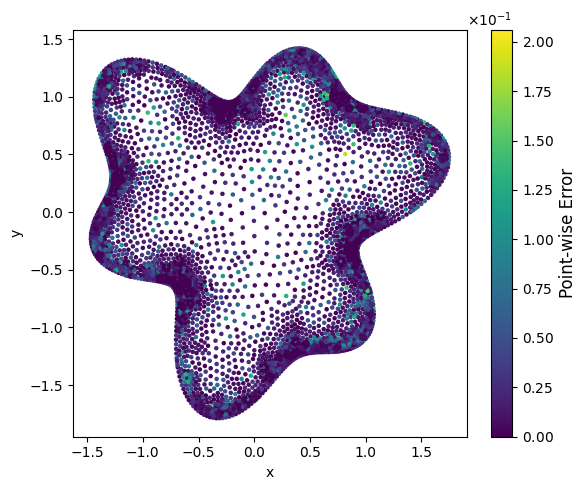

In [ ]:
import matplotlib.ticker as ticker

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

# u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
# u0_func = lambda x, y : 1 + np.sin(x) * np.cos(y)

tau = 1e-3
T = 2e-1 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

data = loadmat('./data/mydata_heat_pdetool_4029_T2e-1_tau1e-3.mat')
#'u0_0', 'uT_0', 'U0_new','UT_new', 'p','in','bc'
# (M,1), (M,NT),  (M,100), (100,M,NT)
p,u0_0,uT_0,U0_new,UT_new, index_in,index_bc = data['p'],data['u0_0'],data['uT_0'],data['U0_new'],data['UT_new'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print("UT_new.shape,", UT_new.shape) # (n_batch,M,NT)

torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2

U0_new = np.concatenate([U0_new[index_in,:],U0_new[index_bc,:]],axis=0)
testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
u0_func = U0_new[:,testnum]  # (M,)
order = 3
scheme = "BDF2"

reg = 1e-12
u_true = UT_new[testnum,:,:]
# print(u_true.shape) # (M,NT)
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
# print(u_true.shape) # print(u_true.shape) # (M,NT)

# #===========================================================
# #==================== Source points X ====================
# #===========================================================
N_patch_grid = 6
N_local_per_patch = 130
N_boundary = 200
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, ptch, _ , _ = generator_points_star(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch=R_ptch, mode = mode)
X = np.vstack([X_inner, X_boundary])
print(f"X.shape",X.shape)

# # ===========================================================
U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat_QR(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme=scheme)

# print("U.shape ",U.shape) #(M,NT)
error = np.abs(U- u_true)
error = np.max(np.max(error))

print(f'p = {order}; L infity error in u_rfmfd_pu: {error:.3e}')
error_u = relative_l2(U.ravel(), u_true.ravel())
print(f'p = {order}; Relative L2 error in u_rfmfd_pu: {error_u:.3e}')

error_u = relative_l2(U[:,-1:], u_true[:,-1:])
print(f'p = {order}; Relative L2 error at T time of u_rfmfd_pu: {error_u:.3e}')

e = np.abs(U[:,-1].ravel() - u_true[:,-1].ravel())
e =np.asarray(e)

for i in range(Nt):
    err_time = relative_l2(U[:,i], u_true[:,i])
    print(f'Time step {i}, Relative L2 error: {err_time:.3e}')

plt.figure(figsize=(6,5))
print(Y[:,0].shape, Y[:,1].shape, e.shape)
sc = plt.scatter(Y[:,0], Y[:,1], c = e, cmap='viridis', s=5)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_error_200_size{M}.eps', bbox_inches='tight')
plt.show()


UT_new.shape  (100, 4029, 201)
After reordering, U0_new.shape  (4029, 100)
p = 3, inference time: 32.1508 秒
error_L2.shape: (100, 1), error_inf.shape: (100, 4029, 201)
p = 3, test on 100 samples. The mean of max error: 3.500292e-01, and mean of relative L2 error: 4.368908e-02
p = 3, test on 100 samples. The variance of max error: 1.139444e-02, and variance of relative L2 error: 1.115994e-04


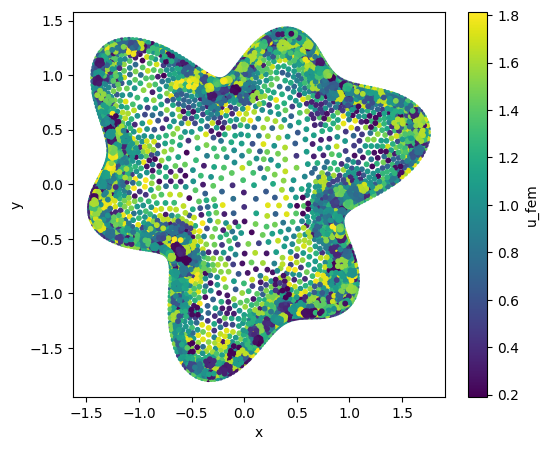

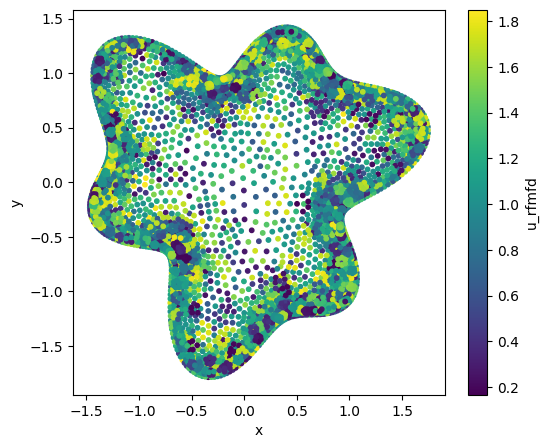

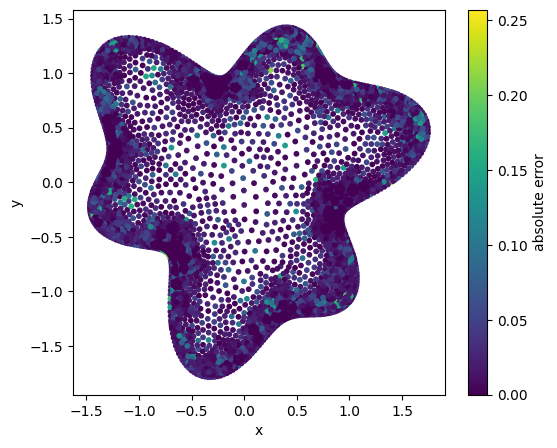

In [15]:


import time

E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points


u_true = UT_new # (100,M,NT)
print( "UT_new.shape ", u_true.shape) 
u_true = np.concatenate([u_true[:,index_in,:],u_true[:,index_bc,:]], axis=1)

print("After reordering, U0_new.shape ", U0_new.shape) #(M,100)


start_time = time.time()
UY = test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, U0_new,
                Yin, Yb, t, tau,
                scheme="BDF2") 
# UY =  np.transpose(UY, (2, 0, 1)) # (n_batch, M, NT)
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")


error_inf = np.abs(UY - u_true) # (n_batch, M, NT)
E_inf =  np.max(np.max(error_inf, axis=2), axis=1) # (n_batch, 1)
error_L2 = (np.linalg.norm(UY - u_true, axis=(1,2)) / np.linalg.norm(u_true, axis=(1,2)))[:, None] # (n_batch, 1)
print(f"error_L2.shape: {error_L2.shape}, error_inf.shape: {error_inf.shape}") #(n_batch,1), (n_batch,M,NT)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")

np.random.seed(100)
q = np.random.randint(0, 100)
u_true_q = u_true[q,:,-1]
UY_q = UY[q,:,-1]
error_inf_q = error_inf[q,:,-1]


plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = u_true_q, cmap='viridis', s=10)
plt.colorbar(label='u_fem')
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/heat_rfmfd_p={order}_u_fem_one_test_sample.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = UY_q, cmap='viridis', s=10)
plt.colorbar(label='u_rfmfd')
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/heat_rfmfd_p={order}_UY_one_test_sample.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = error_inf_q, cmap='viridis', s=10)
plt.colorbar(label='absolute error')
# plt.title(f'Argumented RFM-FD\' point wise error with {order} order polynomial')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/heat_rfmfd_p={order}_error_one_test_sample.eps', bbox_inches='tight')
plt.show()



In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    plt.savefig('L.eps', bbox_inches='tight')
    plt.show()
spy_like_matlab(L)

NameError: name 'L' is not defined

In [ ]:
for name, param in Phi.named_parameters():
    print(name, param.data)